In [2]:
%cd ..

/scratch/big/home/daawic/BSc-Thesis


In [3]:
import os
import torch
import matplotlib.pyplot as plt
import scienceplots
from tqdm import tqdm
from torchvision.transforms import transforms
from project.models import EDMMauMau, EDMSerie
from project.agents import DQNAgent, DiffusionAgent, DenoisingAgent
from project.util.filters import MedianFilter
from project.util.data import ReplayMemoryData
from project.util.metrics import PSNR, MSE

In [4]:
plt.style.use(['science','no-latex', 'nature'])

In [ ]:
GAME = "Breakout"
PATH = os.path.join("..", "checkpoints", "diff", f"{GAME}.pt")
DATA = os.path.join("..", "checkpoints", "memory", f"{GAME}.pt")
DQN = os.path.join("..", "checkpoints", "dqn", f"{GAME}.pt")
N = 8
SIGMA_NOISE_START = 0.1
SIGMA_NOISE_END = 1
NOISE_LEVELS = 9
SAMPLES = 10
N_ACTIONS = 4

In [6]:
device = "cuda:7"

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

In [8]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500_000,
    train=False,
)

In [9]:
model_full = EDMSerie.from_checkpoint(PATH, device, sigma_noise=SIGMA_NOISE_START, N=N).to(device)
model_naive = EDMMauMau.from_checkpoint(PATH, device, sigma_noise=SIGMA_NOISE_START).to(device)
filter = MedianFilter()

In [10]:
agent_base = DQNAgent(
    train=False,
    n_actions=N_ACTIONS
).load(DQN).to(device)
agent_median = DenoisingAgent(
    denoiser=filter,
    train=False,
    n_actions=N_ACTIONS
).load(DQN).to(device)
agent_naive = DiffusionAgent(
    model=model_naive,
    sigma_noise=SIGMA_NOISE_START,
    train=False,
    n_actions=N_ACTIONS
).load(DQN).to(device)
agent_full = DiffusionAgent(
    model=model_full,
    sigma_noise=SIGMA_NOISE_START,
    train=False,
    n_actions=N_ACTIONS
).load(DQN).to(device)

0.0001
0.00025
0.00025
0.00025


In [14]:
q_values_base = torch.zeros((NOISE_LEVELS, SAMPLES))
q_values_base_clean = torch.zeros_like(q_values_base)
q_values_median = torch.zeros_like(q_values_base)
q_values_naive = torch.zeros_like(q_values_base)
q_values_full = torch.zeros_like(q_values_base)

x = torch.zeros((SAMPLES, 4, 84, 84), device=device)

for i, img in enumerate(torch.randperm(500_000)[:SAMPLES]):
    x[i] = data[img].to(device)

sigmas = torch.linspace(SIGMA_NOISE_START, SIGMA_NOISE_END, NOISE_LEVELS)

for i, sigma in enumerate(sigmas):

    agent_full.set_sigma_noise(sigma)
    agent_naive.set_sigma_noise(sigma)

    e = sigma * torch.randn_like(x)
    x_noisy = x + e

    with torch.no_grad():

        for j in tqdm(range(SAMPLES)):

            q_values_base_clean[i, j], a = agent_base.q_values(x[j]).squeeze().max(dim=0)
            
            a = a.item()

            q_values_base[i, j] = agent_base.q_values(x_noisy[j])[0, a]
            q_values_median[i, j] = agent_median.q_values(x_noisy[j])[0, a]
            q_values_naive[i, j] = agent_naive.q_values(x_noisy[j])[0, a]
            q_values_full[i, j] = agent_full.q_values(x_noisy[j])[0, a]

100%|██████████| 10/10 [00:08<00:00,  1.18it/s]


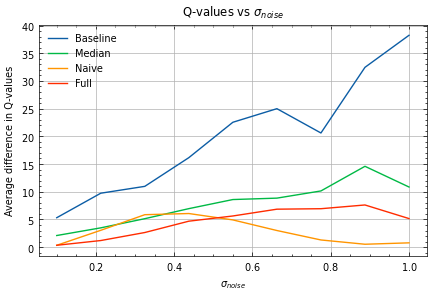

In [ ]:
plt.figure(figsize=(5, 3))

clean = q_values_base_clean.mean(dim=1)
base = (q_values_base.mean(dim=1) - clean).abs()
median = (q_values_median.mean(dim=1) - clean).abs()
naive = (q_values_naive.mean(dim=1) - clean).abs()
full = (q_values_full.mean(dim=1) - clean).abs()

plt.plot(sigmas, base, label="Baseline")
plt.plot(sigmas, median, label="Median")
plt.plot(sigmas, naive, label="Naive")
plt.plot(sigmas, full, label="Full")

plt.xlabel("$\\sigma_{noise}$")
plt.ylabel("Q")
plt.title("Average Q-value difference vs $\\sigma_{noise}$" + f" ({GAME})")

plt.legend()
plt.grid()

plt.savefig("q_values.svg")
plt.show()